In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [45]:
#não tem nenhum algorítmo explícito na apostila, mas utilizei ela como base
def euler(f, x0, y0, h, n):
    #floor não funciona muito bem por causa de divisões estranhas de floats, ex: 0.3/0.1 = 2.9999999999999996
    x = np.zeros(n+1)
    y = np.zeros(n+1)
    x[0] = x0
    y[0] = y0
    for i in range(1,n+1):    
        x[i] = x[i-1] + h
        y[i] = y[i-1] + h*f(x[i-1],y[i-1])
    
    return (x,y)

def heun(f, x0, y0, h, n):
    x = np.zeros(n+1)
    y = np.zeros(n+1)
    x[0] = x0
    y[0] = y0
    for i in range(1,n+1):
        K1 = f(x[i-1], y[i-1]) 
        K2 = f(x[i-1] + h/3.0, y[i-1] + h*K1/3.0)
        K3 = f(x[i-1] + 2.0*h/3.0, y[i-1] + 2.0*h*K2/3.0)
        y[i] = y[i-1] + h*(K1 + 3.0*K3)/4.0
        x[i] = x[i-1] + h

    return (x,y)

#é facilmente generalizado para sistemas de equações diferenciais
def rk4(f, x0, y0, h, n):
    x = np.zeros(n+1)
    y = np.zeros(n+1)
    x[0] = x0
    y[0] = y0
    for i in range(1,n+1):
        K1 = f(x[i-1], y[i-1])
        K2 = f(x[i-1] + h/2.0, y[i-1] + h*K1/2.0)
        K3 = f(x[i-1] + h/2.0, y[i-1] + h*K2/2.0)
        K4 = f(x[i-1] + h, y[i-1] + h*K3)
        y[i] = y[i-1] + h*(K1 + 2.0*K2 + 2.0*K3 + K4)/6.0
        x[i] = x[i-1] + h

    return (x,y)

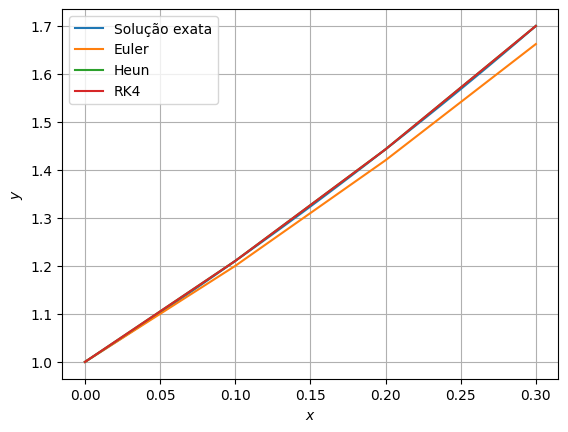

In [46]:
h = 0.1
df = lambda x,y: 1 + y
f = lambda x: 2*np.exp(x) - 1
x0 = 0.0
y0 = 1.0
n = 3
xmax = x0 + n*h

x1,y1 = euler(df, x0, y0, h, n)
x2,y2 = heun(df, x0, y0, h, n)
x3,y3 = rk4(df, x0, y0, h, n)

xvals = np.linspace(x0, xmax, 100)
plt.plot(xvals, f(xvals), label="Solução exata")
plt.plot(x1, y1, label='Euler')
plt.plot(x2, y2, label='Heun')
plt.plot(x3, y3, label='RK4')
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.legend(["Solução exata", "Euler", "Heun", "RK4"])
plt.grid()
plt.show()